In [1]:
import pandas as pd
from pathlib import Path

RUTA_CLIMA = Path("../Datos/Staging/clima_limpio.csv")

# Tipos ligeros: el CSV pesa ~750 MB; cargarlo de golpe suele dar "out of memory"
DTYPES = {
    "BARRIO": "category",
    "summary": "category",
    "precipIntensity": "float32",
    "precipProbability": "float32",
    "temperature": "float32",
    "dewPoint": "float32",
    "humidity": "float32",
    "windSpeed": "float32",
    "windBearing": "float32",
    "cloudCover": "float32",
    "uvIndex": "float32",
    "visibility": "float32",
}

COLUMNAS_SIN_NULOS = [
    "windSpeed",
    "cloudCover",
    "visibility",
    "uvIndex",
    "humidity",
    "temperature",
    "dewPoint",
]

CHUNK_SIZE = 500_000
partes = []

for i, chunk in enumerate(
    pd.read_csv(
        RUTA_CLIMA,
        chunksize=CHUNK_SIZE,
        parse_dates=["TW"],
        dtype=DTYPES,
    ),
    start=1,
):
    antes = len(chunk)
    chunk = chunk.dropna(subset=COLUMNAS_SIN_NULOS)
    partes.append(chunk)
    print(f"  Bloque {i}: {len(chunk):,} filas ({antes - len(chunk):,} con nulos eliminadas)")

clima = pd.concat(partes, ignore_index=True)
del partes

print(f"\nFilas: {len(clima):,}")
print(f"Memoria aprox.: {clima.memory_usage(deep=True).sum() / 1e9:.2f} GB")
print(f"Columnas: {list(clima.columns)}")
clima.head()

  Bloque 1: 500,000 filas (0 con nulos eliminadas)
  Bloque 2: 500,000 filas (0 con nulos eliminadas)
  Bloque 3: 500,000 filas (0 con nulos eliminadas)
  Bloque 4: 500,000 filas (0 con nulos eliminadas)
  Bloque 5: 500,000 filas (0 con nulos eliminadas)
  Bloque 6: 500,000 filas (0 con nulos eliminadas)
  Bloque 7: 500,000 filas (0 con nulos eliminadas)
  Bloque 8: 500,000 filas (0 con nulos eliminadas)
  Bloque 9: 500,000 filas (0 con nulos eliminadas)
  Bloque 10: 500,000 filas (0 con nulos eliminadas)
  Bloque 11: 500,000 filas (0 con nulos eliminadas)
  Bloque 12: 500,000 filas (0 con nulos eliminadas)
  Bloque 13: 500,000 filas (0 con nulos eliminadas)
  Bloque 14: 500,000 filas (0 con nulos eliminadas)
  Bloque 15: 436,188 filas (0 con nulos eliminadas)

Filas: 7,436,188
Memoria aprox.: 1.27 GB
Columnas: ['TW', 'BARRIO', 'summary', 'precipIntensity', 'precipProbability', 'temperature', 'dewPoint', 'humidity', 'windSpeed', 'windBearing', 'cloudCover', 'uvIndex', 'visibility']


,TW,BARRIO,summary,precipIntensity,precipProbability,temperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,0.0,0.0,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,0.0,0.0,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004
2,2017-01-01 02:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,1.02,90.0,0.44,0.0,2.997
3,2017-01-01 03:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,2.09,140.0,0.44,0.0,0.199
4,2017-01-01 04:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,2.09,350.0,1.00,0.0,0.099


In [2]:
nulos = clima.isnull().sum()
porcentaje = (clima.isnull().mean() * 100).round(4)
tabla_nulos = (
    pd.DataFrame({"Nulos": nulos, "Porcentaje (%)": porcentaje})
    .sort_values("Nulos", ascending=False)
)
print(f"Total filas: {len(clima):,}")
print(f"Filas con al menos un nulo: {clima.isnull().any(axis=1).sum():,}\n")
tabla_nulos


Total filas: 7,436,188
Filas con al menos un nulo: 0



,Nulos,Porcentaje (%)
TW,0,0.0
BARRIO,0,0.0
summary,0,0.0
precipIntensity,0,0.0
precipProbability,0,0.0
temperature,0,0.0
dewPoint,0,0.0
humidity,0,0.0
windSpeed,0,0.0
windBearing,0,0.0


## Distribución de variables numéricas

Para cada columna numérica: **histograma** (izquierda) y **boxplot** (derecha).

Se usa una muestra aleatoria de **100.000** filas para que los gráficos respondan bien.

In [7]:
import matplotlib.pyplot as plt

numericas = clima.select_dtypes(include="number").columns.tolist()
muestra = clima[numericas].sample(n=min(100_000, len(clima)), random_state=42)

def graficar_hist_box(columnas, bins=50):
    """Una figura por variable: histograma | boxplot."""
    for col in columnas:
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        datos = muestra[col].dropna()

        axes[0].hist(datos, bins=bins, edgecolor="black", color="steelblue")
        axes[0].set_title(f"Histograma de {col}")
        axes[0].set_xlabel(col)
        axes[0].set_ylabel("Frecuencia")
        axes[0].ticklabel_format(style="plain", axis="y")

        axes[1].boxplot(datos, vert=True)
        axes[1].set_title(f"Boxplot de {col}")
        axes[1].set_ylabel(col)

        plt.tight_layout()
        plt.show()


### Precipitación

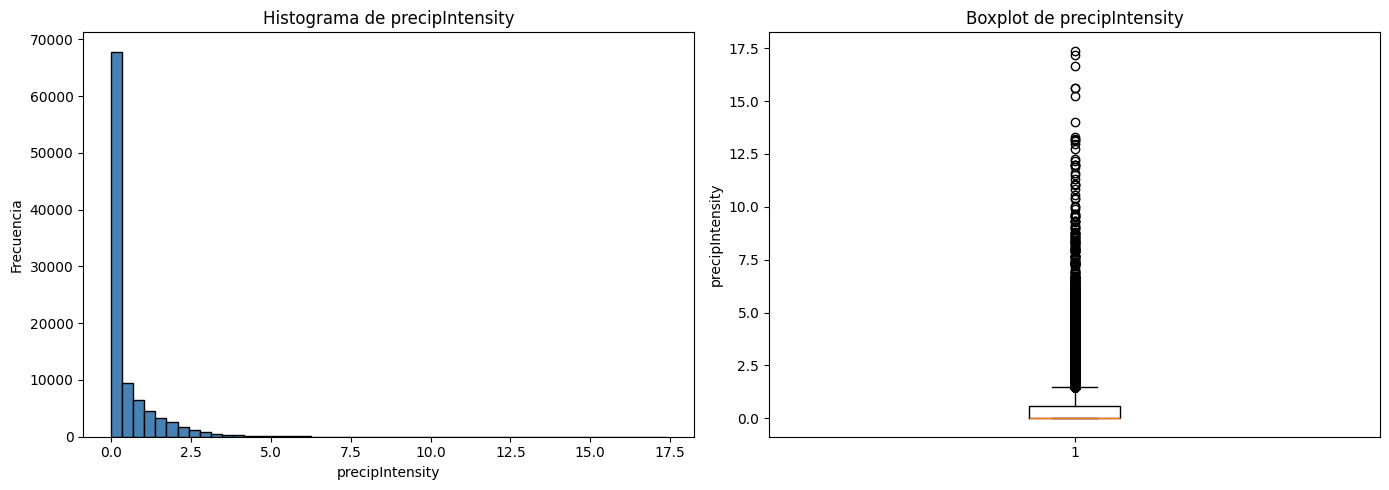

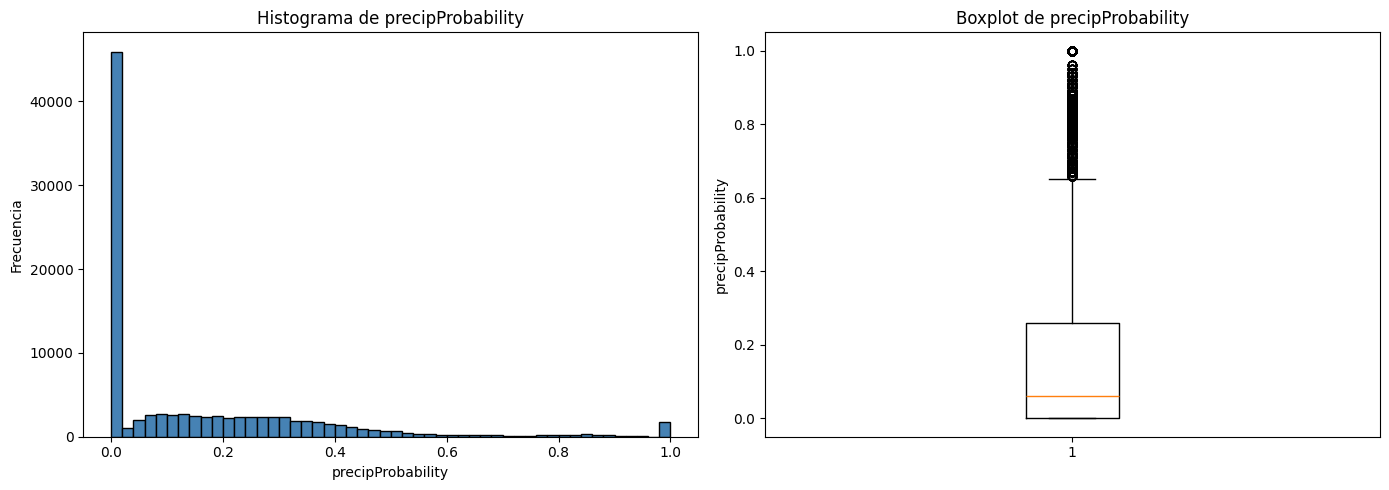

In [8]:
graficar_hist_box(["precipIntensity", "precipProbability"])

### Temperatura y humedad

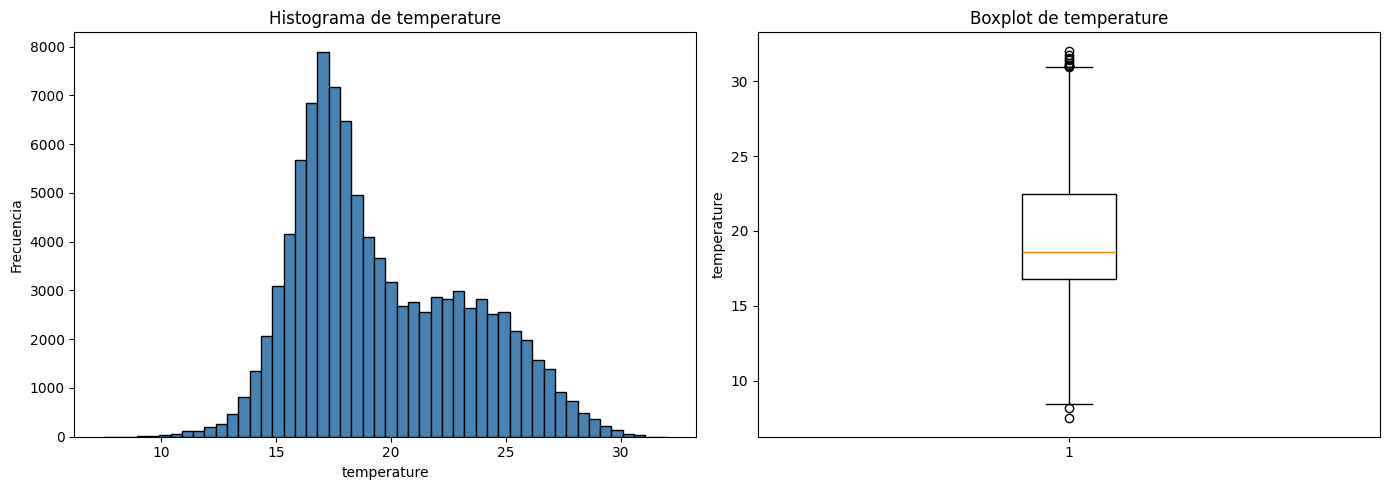

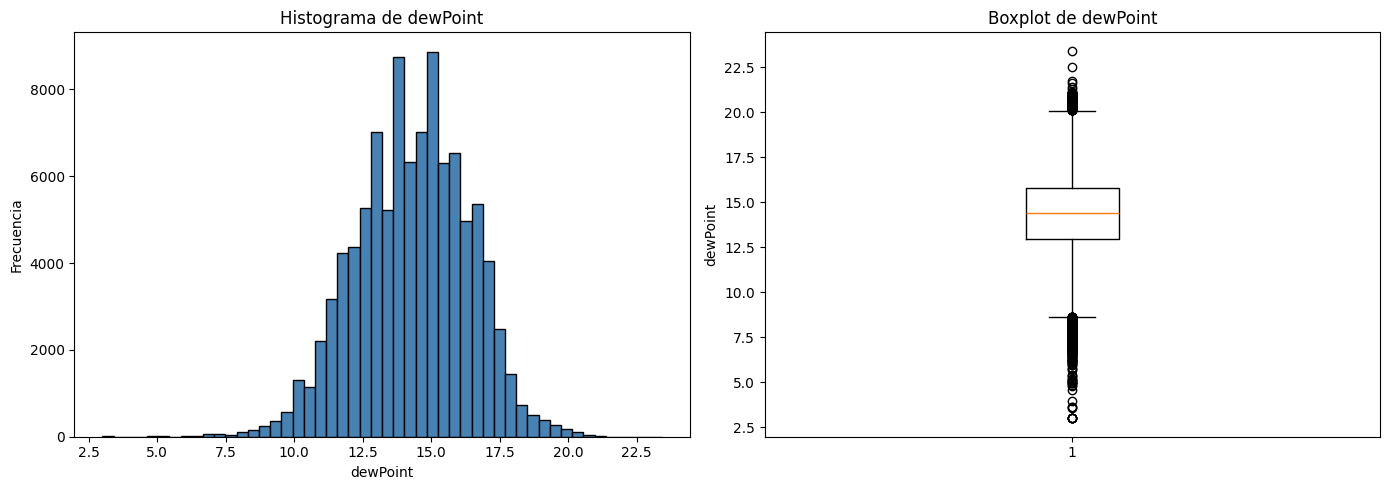

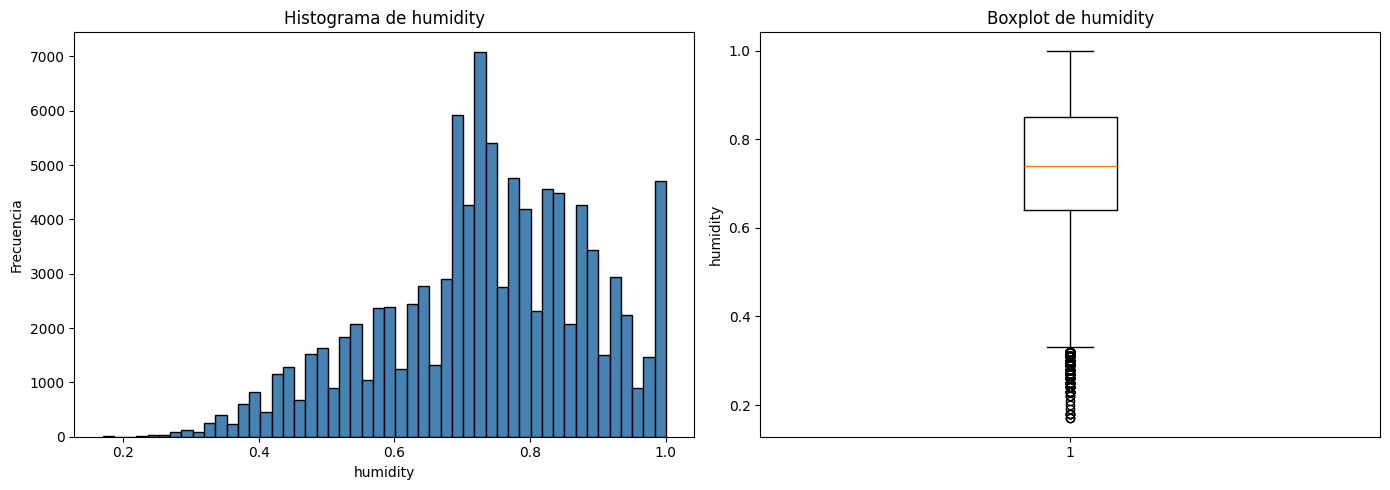

In [9]:
graficar_hist_box(["temperature", "dewPoint", "humidity"])

### Viento

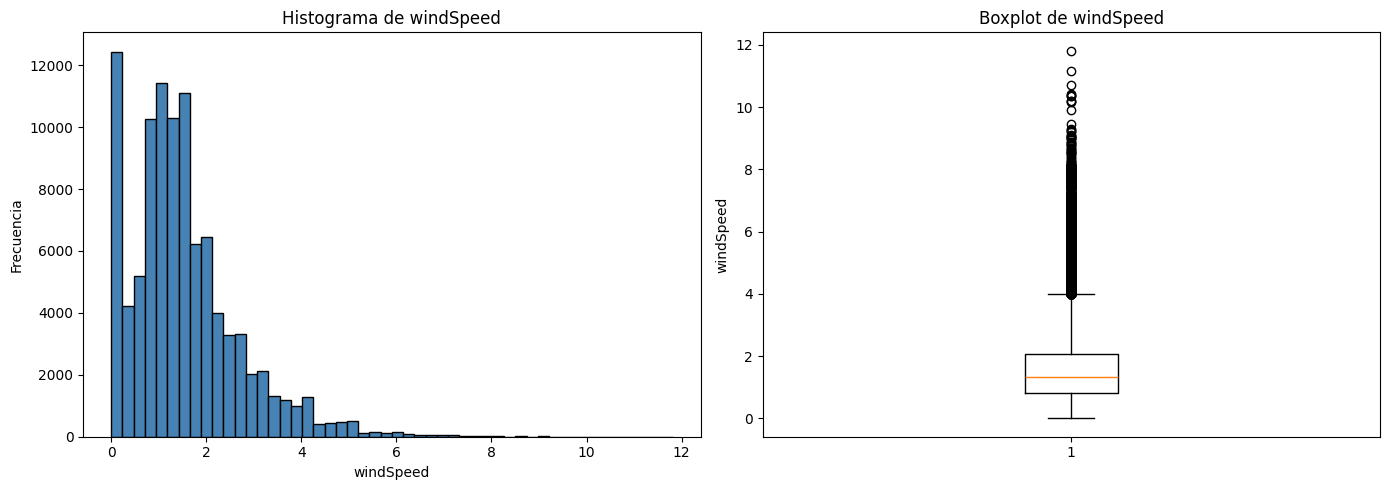

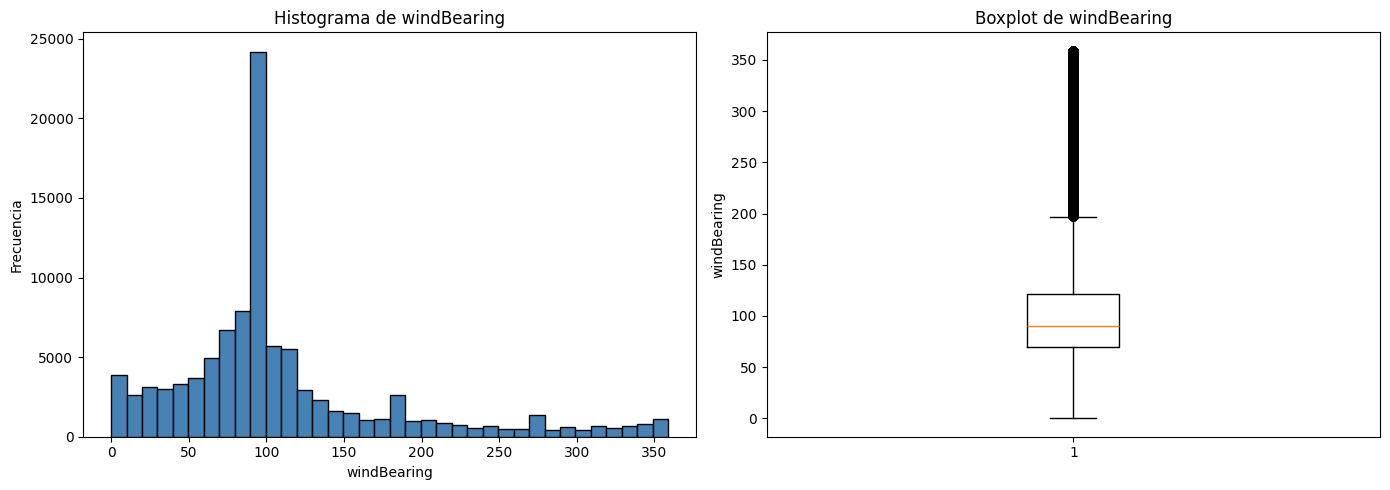

In [10]:
graficar_hist_box(["windSpeed"])
graficar_hist_box(["windBearing"], bins=36)

### Nubosidad, UV y visibilidad

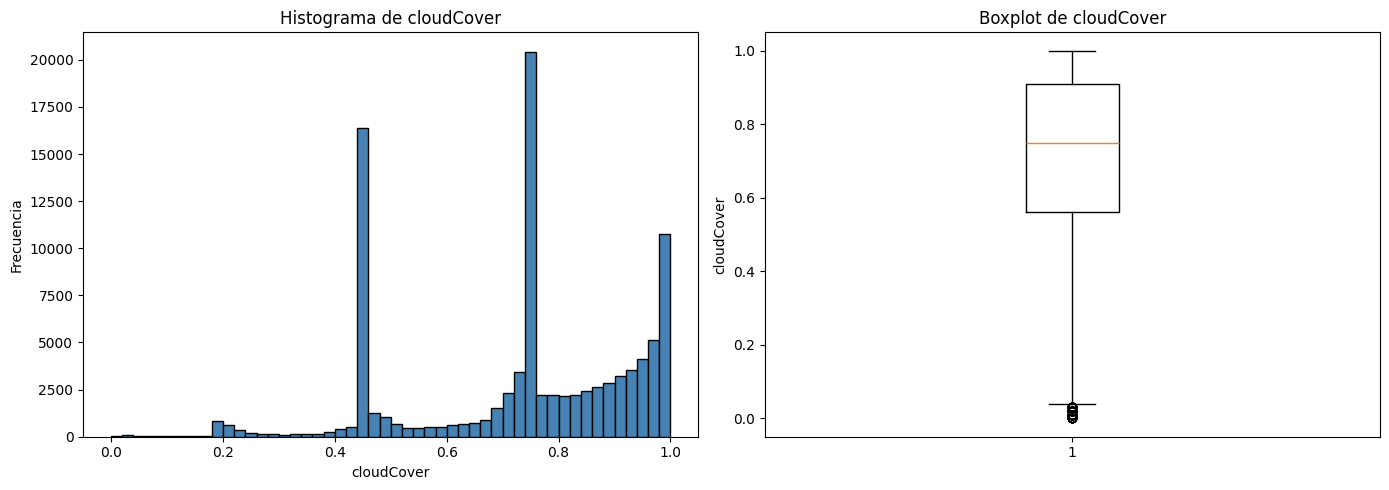

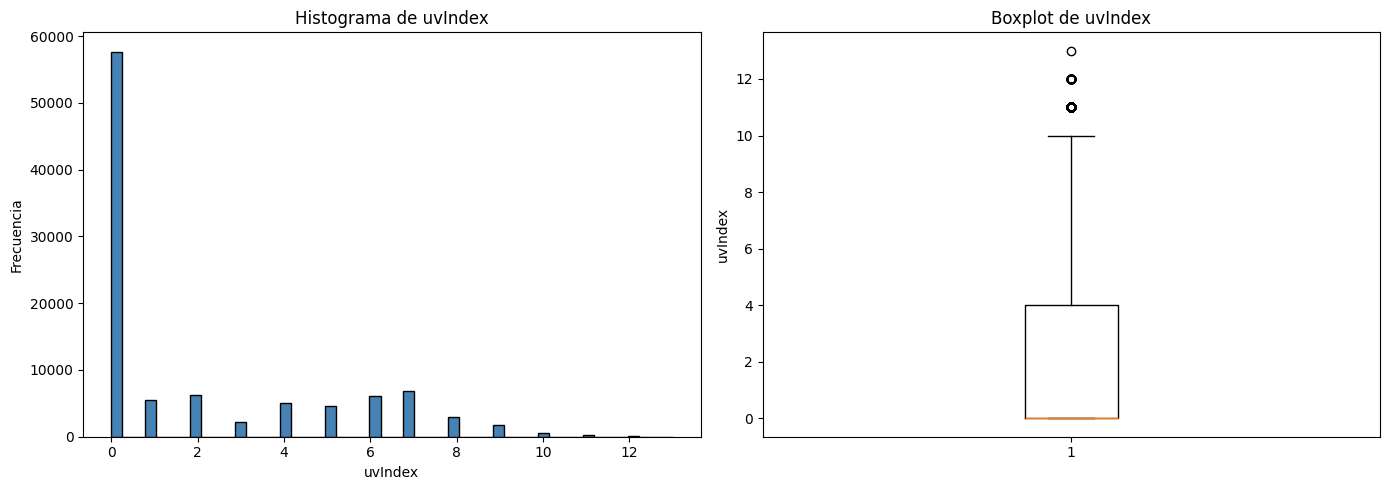

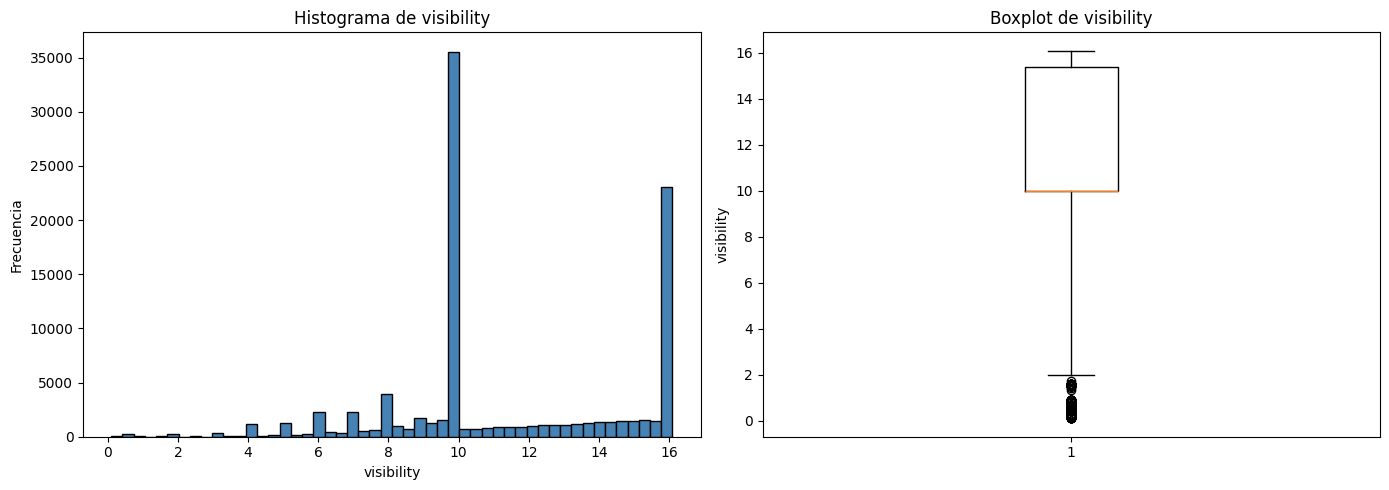

In [11]:
graficar_hist_box(["cloudCover", "uvIndex", "visibility"])

## Media, mediana y moda

Resumen de tendencia central para cada variable numérica (sobre el dataset completo cargado en memoria).

In [12]:
numericas = clima.select_dtypes(include="number").columns.tolist()

def moda_serie(serie):
    valores = serie.mode()
    return valores.iloc[0] if len(valores) else float("nan")

estadisticas = pd.DataFrame({
    "Media": clima[numericas].mean(),
    "Mediana": clima[numericas].median(),
    "Moda": clima[numericas].apply(moda_serie),
}).round(4)

print(f"Variables numéricas: {len(numericas)} | Filas: {len(clima):,}\n")
estadisticas

Variables numéricas: 10 | Filas: 7,436,188



,Media,Mediana,Moda
precipIntensity,0.476300,0.030300,0.000000
precipProbability,0.159600,0.060000,0.000000
temperature,19.585199,18.549999,17.040001
dewPoint,14.324400,14.400000,14.000000
humidity,0.736300,0.740000,0.710000
windSpeed,1.514800,1.330000,0.000000
windBearing,108.090698,90.000000,90.000000
cloudCover,0.729700,0.750000,0.750000
uvIndex,2.007800,0.000000,0.000000
visibility,11.462400,10.003000,10.003000


## Varianza

Dispersión de cada variable numérica sobre el dataset completo (muestra lo grande la variabilidad de cada columna).

In [14]:
numericas = clima.select_dtypes(include="number").columns.tolist()

varianza = clima[numericas].var().round(4)
tabla_varianza = pd.DataFrame({"Varianza": varianza}).sort_values("Varianza", ascending=False)

print(f"Filas: {len(clima):,}\n")
tabla_varianza

Filas: 7,436,188



,Varianza
windBearing,5491.63623
temperature,13.80720
visibility,11.89050
uvIndex,8.27380
dewPoint,4.25340
windSpeed,1.35590
precipIntensity,0.79580
precipProbability,0.04820
cloudCover,0.04300
humidity,0.02380


## Cuartiles

Cuartiles de cada variable numérica: **Q1** (25 %), **Q2** (mediana, 50 %) y **Q3** (75 %).

In [15]:
numericas = clima.select_dtypes(include="number").columns.tolist()

cuartiles = clima[numericas].quantile([0.25, 0.5, 0.75]).T
cuartiles.columns = ["Q1 (25%)", "Q2 / Mediana (50%)", "Q3 (75%)"]
cuartiles = cuartiles.round(4)

print(f"Filas: {len(clima):,}\n")
cuartiles

Filas: 7,436,188



,Q1 (25%),Q2 / Mediana (50%),Q3 (75%)
precipIntensity,0.000,0.0303,0.6061
precipProbability,0.000,0.0600,0.2600
temperature,16.800,18.5500,22.4100
dewPoint,12.950,14.4000,15.8000
humidity,0.650,0.7400,0.8500
windSpeed,0.800,1.3300,2.0600
windBearing,70.000,90.0000,121.0000
cloudCover,0.570,0.7500,0.9100
uvIndex,0.000,0.0000,4.0000
visibility,10.003,10.0030,15.4110


## Desviación estándar

Mide la dispersión de cada variable numérica en las mismas unidades que la variable (a diferencia de la varianza, que está al cuadrado).

In [19]:
numericas = clima.select_dtypes(include="number").columns.tolist()

desviacion = clima[numericas].std().round(4)
tabla_std = pd.DataFrame({"Desviación estándar": desviacion}).sort_values(
    "Desviación estándar", ascending=False
)

print(f"Filas: {len(clima):,}\n")
tabla_std

Filas: 7,436,188



,Desviación estándar
windBearing,74.105598
temperature,3.715800
visibility,3.448300
uvIndex,2.876400
dewPoint,2.062400
windSpeed,1.164400
precipIntensity,0.892100
precipProbability,0.219600
cloudCover,0.207300
humidity,0.154300


In [13]:
numericas = clima.select_dtypes(include="number")

Q1 = numericas.quantile(0.25)
Q3 = numericas.quantile(0.75)
IQR = Q3 - Q1

lim_inf = Q1 - 1.5 * IQR
lim_sup = Q3 + 1.5 * IQR

out_inf = (numericas < lim_inf).sum()
out_sup = (numericas > lim_sup).sum()
total_out = out_inf + out_sup
porcentaje = (total_out / numericas.count() * 100).round(2)

resumen = pd.DataFrame({
    "Límite inferior": lim_inf.round(2),
    "Outliers (inf)": out_inf,
    "Límite superior": lim_sup.round(2),
    "Outliers (sup)": out_sup,
    "Total outliers": total_out,
    "Porcentaje (%)": porcentaje
}).sort_values("Total outliers", ascending=False)

resumen

,Límite inferior,Outliers (inf),Límite superior,Outliers (sup),Total outliers,Porcentaje (%)
windBearing,-6.50,0,197.50,853177,853177,11.47
precipIntensity,-0.91,0,1.52,774571,774571,10.42
windSpeed,-1.09,0,3.95,333842,333842,4.49
precipProbability,-0.39,0,0.65,327376,327376,4.40
humidity,0.35,59351,1.15,0,59351,0.80
dewPoint,8.67,33382,20.08,13926,47308,0.64
visibility,1.89,32768,23.52,0,32768,0.44
uvIndex,-6.00,0,10.00,23986,23986,0.32
cloudCover,0.06,13335,1.42,0,13335,0.18
temperature,8.38,288,30.83,1731,2019,0.03


## Join con accidentes

Carga `accidentes_staging.csv` y prepara una tabla por `BARRIO` + `TW` para hacer **left join** con `clima` (cada fila de clima conserva su clima; si hubo accidente en ese barrio y hora, se marca).

In [23]:
RUTA_ACCIDENTES = Path("../Datos/Staging/accidentes_staging.csv")

accidentes = pd.read_csv(RUTA_ACCIDENTES, parse_dates=["TW"])

# Una fila por BARRIO + TW (evita duplicar filas de clima en el merge)
accidentes_target = (
    accidentes.groupby(["BARRIO", "TW"], as_index=False)
    .agg(
        n_accidentes=("GRAVEDAD", "size"),
        target=("GRAVEDAD", lambda _: 1),
    )
)

print(f"Accidentes (registros): {len(accidentes):,}")
print(f"Claves únicas BARRIO + TW: {len(accidentes_target):,}")
accidentes_target.head()

C:\Users\camil\AppData\Local\Temp\ipykernel_12932\3445714688.py:3: DtypeWarning: Columns (0: RADICADO) have mixed types. Specify dtype option on import or set low_memory=False.
  accidentes = pd.read_csv(RUTA_ACCIDENTES, parse_dates=["TW"])


Accidentes (registros): 125,122
Claves únicas BARRIO + TW: 120,587


,BARRIO,TW,n_accidentes,target
0,aguasfrias,2017-02-05 22:00:00,1,1
1,aguasfrias,2017-02-25 23:00:00,1,1
2,aguasfrias,2017-03-04 23:00:00,1,1
3,aguasfrias,2017-06-02 17:00:00,1,1
4,aguasfrias,2017-06-11 13:00:00,1,1


In [25]:
df = clima.merge(
    accidentes_target,
    on=["BARRIO", "TW"],
    how="left"
)
df

,TW,BARRIO,summary,precipIntensity,precipProbability,temperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility,n_accidentes,target
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,0.0000,0.00,16.43,14.00,0.86,1.50,0.0,0.44,0.0,6.004,NaN,NaN
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,0.0000,0.00,16.43,14.00,0.86,1.50,0.0,0.44,0.0,6.004,NaN,NaN
2,2017-01-01 02:00:00,aguasfrias,Foggy,0.0000,0.00,15.43,13.00,0.85,1.02,90.0,0.44,0.0,2.997,NaN,NaN
3,2017-01-01 03:00:00,aguasfrias,Foggy,0.0000,0.00,15.43,13.00,0.85,2.09,140.0,0.44,0.0,0.199,NaN,NaN
4,2017-01-01 04:00:00,aguasfrias,Foggy,0.0000,0.00,15.43,13.00,0.85,2.09,350.0,1.00,0.0,0.099,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7436183,2019-12-31 19:00:00,yolombo,Rain,3.0905,0.38,15.33,15.33,1.00,1.20,348.0,0.99,0.0,10.165,NaN,NaN
7436184,2019-12-31 20:00:00,yolombo,Rain,2.8501,0.38,15.00,15.00,1.00,1.36,225.0,0.99,0.0,10.737,NaN,NaN
7436185,2019-12-31 21:00:00,yolombo,Possible Light Rain,2.0769,0.40,14.68,14.68,1.00,1.12,152.0,0.99,0.0,14.227,NaN,NaN
7436186,2019-12-31 22:00:00,yolombo,Possible Light Rain,1.7971,0.41,14.34,14.34,1.00,0.66,169.0,0.98,0.0,16.093,NaN,NaN


### NaN → 0 (sin accidente)

Tras el left join, las filas sin accidente quedan con `NaN` en `target` y `n_accidentes`. Las reemplazamos por **0**.

In [26]:
df[["target", "n_accidentes"]] = df[["target", "n_accidentes"]].fillna(0)
df["target"] = df["target"].astype("int8")
df["n_accidentes"] = df["n_accidentes"].astype("int32")

print(f"Filas: {len(df):,}")
print(f"Con accidente (target=1): {(df['target'] == 1).sum():,}")
print(f"Sin accidente (target=0): {(df['target'] == 0).sum():,}")
print(f"NaN restantes: {df[['target', 'n_accidentes']].isna().sum().sum()}")
df.head()

Filas: 7,436,188
Con accidente (target=1): 112,575
Sin accidente (target=0): 7,323,613
NaN restantes: 0


,TW,BARRIO,summary,precipIntensity,precipProbability,temperature,dewPoint,humidity,windSpeed,windBearing,cloudCover,uvIndex,visibility,n_accidentes,target
0,2017-01-01 00:00:00,aguasfrias,Partly Cloudy,0.0,0.0,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004,0,0
1,2017-01-01 01:00:00,aguasfrias,Partly Cloudy,0.0,0.0,16.43,14.0,0.86,1.50,0.0,0.44,0.0,6.004,0,0
2,2017-01-01 02:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,1.02,90.0,0.44,0.0,2.997,0,0
3,2017-01-01 03:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,2.09,140.0,0.44,0.0,0.199,0,0
4,2017-01-01 04:00:00,aguasfrias,Foggy,0.0,0.0,15.43,13.0,0.85,2.09,350.0,1.00,0.0,0.099,0,0


In [27]:
resumen_target = pd.DataFrame({
    "cantidad": df["target"].value_counts(),
    "porcentaje": df["target"].value_counts(normalize=True).mul(100).round(2)
})

resumen_target

,cantidad,porcentaje
target,,
0,7323613,98.49
1,112575,1.51
